## Librerias

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats


## Carga datos clean

In [48]:
df_operaciones = pd.read_csv('C:\\Users\\Usuario\\Desktop\\PROYECTO\\operaciones_09-03-2026.csv', parse_dates=['insert_date'])
df_operaciones

,Unnamed: 0,apartment_id,room_type,price,has_availability,availability_30,availability_60,availability_90,availability_365,review_scores_rating,...,number_of_reviews,reviews_per_month,city,insert_date,reviews 80+,fully_booked,occ_month,occ_2month,occ_3month,occ_year
0,0,11964,Private room,400.0,True,7,20,40,130,97.0,...,78,0.76,Malaga,2018-07-31,True,False,0.766667,0.666667,0.555556,0.643836
1,1,21853,Private room,170.0,True,0,0,0,162,92.0,...,33,0.52,Madrid,2020-01-10,True,False,1.000000,1.000000,1.000000,0.556164
2,2,32347,Entire home/apt,990.0,True,26,31,31,270,98.0,...,148,1.44,Sevilla,2019-07-29,True,False,0.133333,0.483333,0.655556,0.260274
3,3,35379,Private room,400.0,True,9,23,49,300,94.0,...,292,3.10,Barcelona,2020-01-10,True,False,0.700000,0.616667,0.455556,0.178082
4,4,35801,Private room,900.0,True,0,19,49,312,97.0,...,36,0.39,Girona,2019-02-19,True,False,1.000000,0.683333,0.455556,0.145205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6610,6610,27237828,Entire home/apt,1500.0,True,22,47,77,78,100.0,...,1,7.60,Girona,2018-08-30,True,False,0.266667,0.216667,0.144444,0.786301
6611,6611,27241318,Entire home/apt,3130.0,True,26,37,37,243,100.0,...,1,0.74,Mallorca,2020-04-23,True,False,0.133333,0.383333,0.588889,0.334247
6612,6612,27244243,Entire home/apt,990.0,True,24,40,40,40,NaN,...,0,NaN,Girona,2018-08-30,NaN,False,0.200000,0.333333,0.555556,0.890411
6613,6613,27244794,Entire home/apt,720.0,True,0,0,0,0,100.0,...,1,0.07,Girona,2019-12-31,True,True,1.000000,1.000000,1.000000,1.000000


#### Transformación/creación de variables y df

In [49]:
RUTA_FIGURES = Path(r"C:\Users\Usuario\Desktop\PROYECTO")

def guardar_grafico(fig, nombre_archivo, formato="png", dpi=300):
    RUTA_FIGURES.mkdir(parents=True, exist_ok=True)

    ruta_archivo = RUTA_FIGURES / f"{nombre_archivo}.{formato}"

    fig.savefig(ruta_archivo, bbox_inches="tight", dpi=dpi)
    plt.close(fig)

    print(f"Gráfico guardado en: {ruta_archivo}")

In [50]:
total_anuncios = df_operaciones["apartment_id"].nunique()                      
apartamentos_disponibles = df_operaciones["has_availability"].sum()  
apartamentos_disponibles                      
available_30 = (df_operaciones["availability_30"] > 0).sum()                            
ratio_oferta_disponible = round((available_30 / apartamentos_disponibles) * 100, 2)     
fully_booked_active = df_operaciones[
    (df_operaciones["fully_booked"]) & 
    (df_operaciones["has_availability"])
].shape[0]       

Para evitar que el análisis de disponibilidad se vea afectado por anuncios que no aceptan reservas, se filtró el dataset para considerar únicamente los alojamientos con disponibilidad activa (has_availability = True). De este modo, los cálculos reflejan únicamente la oferta realmente disponible en el mercado.

In [51]:
df_activos = df_operaciones[df_operaciones["has_availability"] == True].copy()

## Análisis / visualizaciones
Quina és la disponibilitat mitjana dels allotjaments
turístics en els diferents terminis (30, 60, 90 i 365 dies) a cada ciutat?

In [52]:
palette = sns.color_palette("YlGnBu", 8)
cmap = "YlGnBu"

In [53]:
ratio_oferta_activa = (
    df_operaciones["has_availability"].mean().round(2) * 100
)
ratio_oferta_activa

np.float64(92.0)

#### Disponibilidad media por ciudad

In [54]:
availability_cols = [
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365"
]

disponibilidad_ciudad_raw = (
    df_activos
    .groupby("city")[availability_cols]
    .mean()
    .round(0)
    .reset_index()
    .sort_values(by="availability_30", ascending=True)
)

disponibilidad_ciudad_raw

,city,availability_30,availability_60,availability_90,availability_365
2,Madrid,10.0,24.0,39.0,160.0
0,Barcelona,11.0,26.0,43.0,178.0
3,Malaga,12.0,29.0,47.0,203.0
4,Mallorca,13.0,28.0,44.0,207.0
7,Valencia,13.0,29.0,47.0,183.0
1,Girona,14.0,31.0,48.0,194.0
6,Sevilla,14.0,30.0,49.0,199.0
5,Menorca,15.0,30.0,47.0,198.0


Para poder comparar los distintos horizontes temporales (30, 60, 90 y 365 días), primero se transformaron los valores de disponibilidad en ratios relativos, dividiendo el número de días disponibles entre el total de días de cada periodo. De esta forma se obtiene el porcentaje de disponibilidad. Posteriormente se calculó la media de estos ratios por ciudad, lo que permite realizar comparaciones más justas entre ciudades y horizontes temporales.

In [ ]:
df_activos["avail_ratio_30"] = df_activos["availability_30"] / 30
df_activos["avail_ratio_60"] = df_activos["availability_60"] / 60
df_activos["avail_ratio_90"] = df_activos["availability_90"] / 90
df_activos["avail_ratio_365"] = df_activos["availability_365"] / 365

avail_ratio_cols = [
    "avail_ratio_30",
    "avail_ratio_60",
    "avail_ratio_90",
    "avail_ratio_365"
]

disponibilidad_ciudad_pct = (
    df_activos
    .groupby("city")[avail_ratio_cols]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
)

disponibilidad_ciudad_pct

,city,avail_ratio_30,avail_ratio_60,avail_ratio_90,avail_ratio_365
0,Barcelona,37.7,43.3,47.6,48.8
1,Girona,48.0,51.7,53.4,53.2
2,Madrid,34.0,39.7,43.8,43.8
3,Malaga,40.6,47.7,52.7,55.6
4,Mallorca,42.9,46.3,48.8,56.7
5,Menorca,48.8,50.4,52.4,54.1
6,Sevilla,45.9,50.5,55.0,54.5
7,Valencia,44.8,49.1,52.7,50.2


#### Oferta por ciudad

Para contextualizar la disponibilidad también se analiza
la oferta total de alojamientos por ciudad.

Esto permite interpretar mejor los resultados, ya que una ciudad
puede mostrar baja disponibilidad simplemente porque tiene
pocos alojamientos.

In [71]:
df_ciudad_oferta = (
    df_activos
    .groupby("city")
    .agg(
        oferta_total=("apartment_id", "nunique"),
        oferta_disponible=("availability_30", lambda x: (x > 0).sum()),
        disponibilidad_media=("avail_ratio_30", "mean")
    )
    .reset_index()
)

df_ciudad_oferta["disponibilidad_media"] = (df_ciudad_oferta["disponibilidad_media"] * 100).round(2)
df_ciudad_oferta["ratio_oferta_disponible"] = (
    df_ciudad_oferta["oferta_disponible"] /
    df_ciudad_oferta["oferta_total"] * 100).round(2)
df_ciudad_oferta["ocupacion_media"] = (
    100 - df_ciudad_oferta["disponibilidad_media"]
).round(2)

df_ciudad_oferta

,city,oferta_total,oferta_disponible,disponibilidad_media,ratio_oferta_disponible,ocupacion_media
0,Barcelona,1609,1100,37.70,68.37,62.30
1,Girona,1071,733,48.01,68.44,51.99
2,Madrid,1301,841,33.99,64.64,66.01
3,Malaga,339,257,40.65,75.81,59.35
4,Mallorca,1000,728,42.93,72.80,57.07
5,Menorca,134,88,48.78,65.67,51.22
6,Sevilla,339,286,45.85,84.37,54.15
7,Valencia,294,218,44.83,74.15,55.17


In [58]:
periodos = {
    "30d": ("availability_30", 30),
    "60d": ("availability_60", 60),
    "90d": ("availability_90", 90),
    "365d": ("availability_365", 365)
}
kpi_operaciones = {
    "anuncios_totales": int(total_anuncios)
}

for p, (col, dias) in periodos.items():
    
    disponibles = (df_operaciones[col] > 0).sum()
    
    ocupacion = ((dias - df_operaciones[col]) / dias).mean() * 100
    
    kpi_operaciones[f"disponibles_{p}"] = int(disponibles)
    kpi_operaciones[f"ocupacion_{p}_%"] = round(ocupacion,1)

kpi_operaciones_df = pd.DataFrame(
    list(kpi_operaciones.items()),
    columns=["KPI", "Valor"]
)

kpi_operaciones_df

,KPI,Valor
0,anuncios_totales,6615.0
1,disponibles_30d,4661.0
2,ocupacion_30d_%,59.5
3,disponibles_60d,5057.0
4,ocupacion_60d_%,54.7
5,disponibles_90d,5288.0
6,ocupacion_90d_%,51.1
7,disponibles_365d,5747.0
8,ocupacion_365d_%,48.9


### TEST ANOVA

H0
Todas las ciudades tienen la misma disponibilidad media.

H1 
Al menos una ciudad tiene una media diferente.

Para comprobar si las diferencias observadas en la disponibilidad entre ciudades eran estadísticamente significativas, se realizó un análisis de varianza (ANOVA). El resultado mostró un valor F = 16.80 y un p-value extremadamente bajo (p < 0.001), lo que permite rechazar la hipótesis nula de igualdad de medias. Esto indica que existen diferencias significativas en la disponibilidad media de alojamientos entre las distintas ciudades analizadas.

In [59]:
grupos = [
    grupo["avail_ratio_30"].values
    for name, grupo in df_activos.groupby("city")
]

anova = stats.f_oneway(*grupos)

print("F-statistic:", anova.statistic)
print("p-value:", anova.pvalue)

F-statistic: 15.407684468502104
p-value: 3.934266797539858e-20


## Resultados / archivos generados

Para contextualizar el análisis de disponibilidad se analizó también la diferencia entre oferta total y oferta activa por ciudad. Esto permite entender qué proporción del mercado está realmente disponible para reservas y evita interpretar las diferencias de disponibilidad únicamente como resultado de la demanda.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_11220\2920066393.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_pipeline["city"])


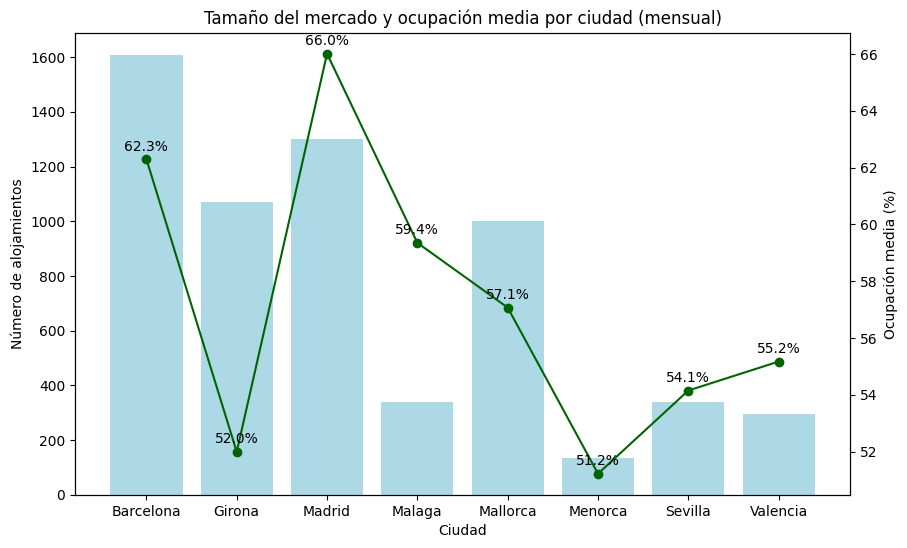

Gráfico guardado en: C:\Users\Usuario\Desktop\PROYECTO\operaciones_comparacion_oferta_ciudad.png


In [80]:
df_pipeline = (
    df_operaciones
    .groupby("city")
    .agg(
        oferta_total=("apartment_id", "nunique"),
        oferta_activa=("has_availability", "sum"),
        oferta_disponible_30=("availability_30", lambda x: (x > 0).sum())
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10,6))

x = np.arange(len(df_pipeline["city"]))
width = 0.25

# barras de oferta
ax1.bar(df_ciudad_oferta["city"], df_ciudad_oferta["oferta_total"], color="lightblue")
ax1.set_ylabel("Número de alojamientos")

# segundo eje para ocupación
ax2 = ax1.twinx()
ax2.plot(
    df_ciudad_oferta["city"],
    df_ciudad_oferta["ocupacion_media"],
    marker="o",
    color="darkgreen"
)

for x, y in zip(df_ciudad_oferta["city"], df_ciudad_oferta["ocupacion_media"]):
    ax2.text(x, y + 0.3, f"{y:.1f}%", ha='center')


ax1.set_xticklabels(df_pipeline["city"])

ax1.set_ylabel("Número de alojamientos")
ax1.set_xlabel("Ciudad")
ax1.set_title("Tamaño del mercado y ocupación media por ciudad (mensual)")
ax2.set_ylabel("Ocupación media (%)")


plt.show()
guardar_grafico(fig,"operaciones_comparacion_oferta_ciudad")

Conclusiones: La disponibilidad de alojamientos aumenta conforme el horizonte temporal es mayor, lo que refleja un comportamiento esperado en mercados turísticos donde las reservas se concentran en el corto plazo. Madrid y Barcelona presentan los niveles más bajos de disponibilidad mensual, lo que sugiere una mayor presión de demanda. En contraste, ciudades como Girona y Menorca muestran mayores niveles de disponibilidad relativa, lo que podría indicar menor demanda o mayor oferta de alojamientos.

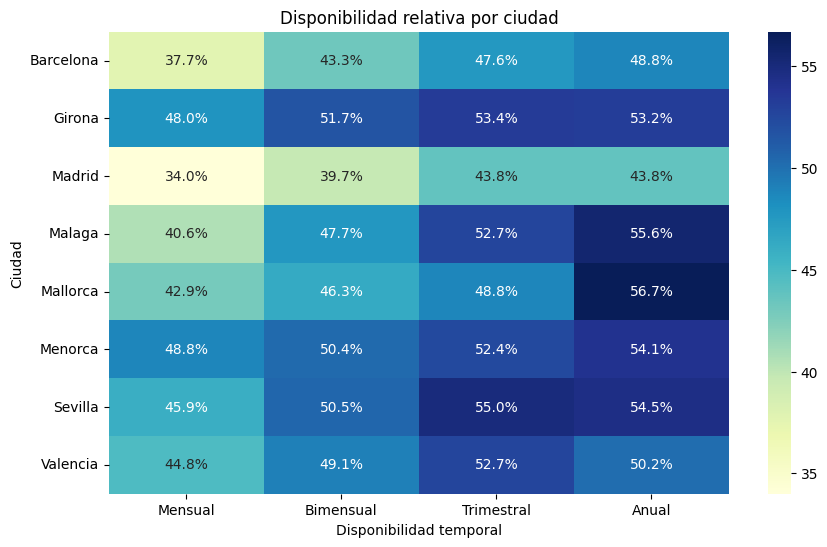

Gráfico guardado en: C:\Users\Usuario\Desktop\PROYECTO\operaciones_heatmap_disponibilidad.png


In [61]:
data = disponibilidad_ciudad_pct.set_index("city")
labels = data.round(2).astype(str) + "%"

fig, ax = plt.subplots(figsize=(10,6))

sns.heatmap(
    data,
    annot=labels,
    cmap=cmap,
    fmt=""
)

ax.set_title("Disponibilidad relativa por ciudad")
ax.set_ylabel("Ciudad")
ax.set_xlabel("Disponibilidad temporal")
ax.set_xticklabels(["Mensual","Bimensual","Trimestral","Anual"])

plt.show()
guardar_grafico(fig,"operaciones_heatmap_disponibilidad")

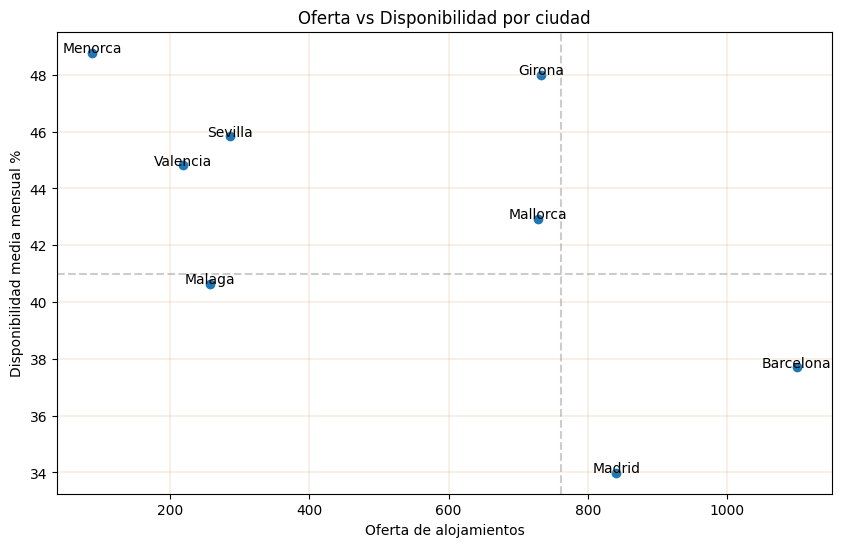

Gráfico guardado en: C:\Users\Usuario\Desktop\PROYECTO\operaciones_scatter_oferta_disponibilidad.png


In [85]:
fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(
    df_ciudad_oferta["oferta_disponible"],
    df_ciudad_oferta["disponibilidad_media"]
)

for i, row in df_ciudad_oferta.iterrows():
    ax.text(
        row["oferta_disponible"],
        row["disponibilidad_media"],
        row["city"],
        ha="center"
    )
media_oferta = df_ciudad_oferta["oferta_total"].mean()

ax.axvline(
    media_oferta,
    linestyle="--",
    color="gray",
    alpha=0.4
)

ax.set_xlabel("Oferta de alojamientos")
ax.set_ylabel("Disponibilidad media mensual %")
ax.set_title("Oferta vs Disponibilidad por ciudad")
ax.axhline(41, color="gray", linestyle="--", alpha=0.4)
ax.grid(True, linewidth=0.3, color="burlywood")

plt.show()
guardar_grafico(fig,"operaciones_scatter_oferta_disponibilidad")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_11220\1578509397.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


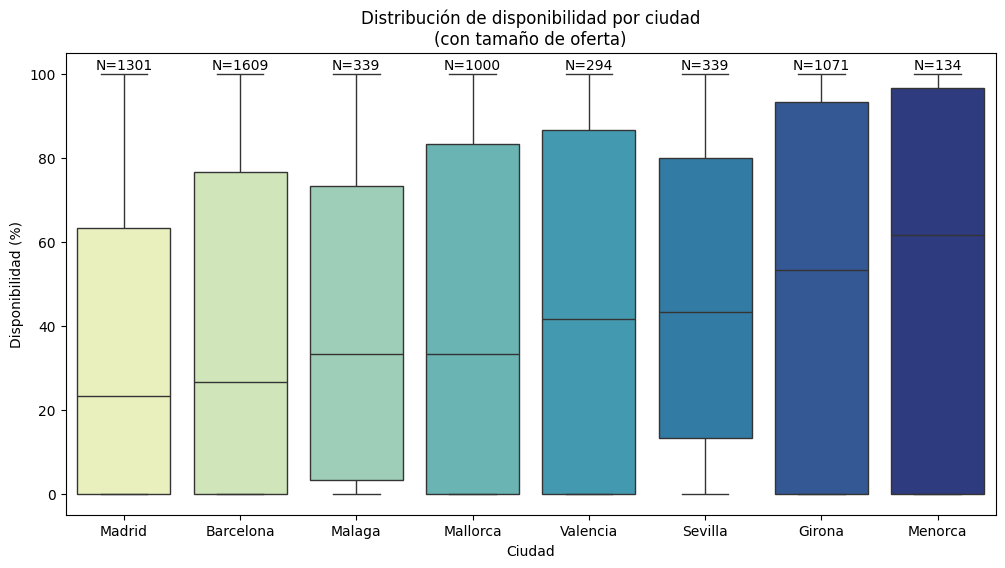

Gráfico guardado en: C:\Users\Usuario\Desktop\PROYECTO\operaciones_boxplot_disponibilidad_ciudad.png


In [63]:
orden = df_ciudad_oferta.sort_values("disponibilidad_media")["city"]
df_activos["avail_ratio_30_pct"] = df_activos["avail_ratio_30"] * 100

fig, ax = plt.subplots(figsize=(12,6))
sns.boxplot(
    data=df_activos,
    x="city",
    y="avail_ratio_30_pct",
    order=orden,
    palette="YlGnBu"
)
for i, city in enumerate(orden):

    oferta = df_ciudad_oferta.loc[
        df_ciudad_oferta["city"] == city,
        "oferta_total"
    ].values[0]

    ax.text(i, 101, f"N={oferta}", ha="center")

ax.set_ylabel("Disponibilidad (%)")
ax.set_xlabel("Ciudad")
ax.set_title("Distribución de disponibilidad por ciudad\n(con tamaño de oferta)")

plt.show()

guardar_grafico(fig,"operaciones_boxplot_disponibilidad_ciudad")

El boxplot muestra diferencias en la distribución de la disponibilidad entre ciudades. Madrid y Barcelona presentan medianas más bajas, lo que sugiere una mayor presión de demanda, mientras que ciudades como Girona y Menorca muestran niveles de disponibilidad más elevados. Aunque existe una variabilidad considerable dentro de cada ciudad, el análisis ANOVA confirma que las diferencias observadas entre ciudades son estadísticamente significativas.